# Walk-Forward (WF1–WF5) Results Comparison

This notebook **extracts the already-computed summary tables** from the existing notebooks:
- `WF1.ipynb` … `WF5.ipynb`

and combines them into a **single comparison** using tables + plots.

Note: This does **not** retrain models or recompute SHAP; it parses the saved notebook outputs.

In [1]:
import json
import re
import html as ihtml
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: f'{x:,.5f}')

In [2]:
# Optional: interactive charts (Plotly)
# If this import fails, run: %pip install plotly
try:
    import plotly.express as px
    import plotly.graph_objects as go

    # Ensure plots render well in VS Code + Jupyter
    import plotly.io as pio
    pio.renderers.default = "notebook_connected"
    PLOTLY_AVAILABLE = True
except Exception as e:
    PLOTLY_AVAILABLE = False
    print("Plotly not available (interactive charts disabled).")
    print("Install with: %pip install plotly")
    print("Reason:", repr(e))

In [3]:
# Locate the folder that contains WF notebooks
candidates = [Path('XAI NOVELTY'), Path('.')]

base_dir = None
for c in candidates:
    if (c / 'WF1.ipynb').exists() and (c / 'WF5.ipynb').exists():
        base_dir = c
        break

if base_dir is None:
    raise FileNotFoundError('Could not find WF1.ipynb..WF5.ipynb in ./ or ./XAI NOVELTY')

wf_paths = [base_dir / f'WF{i}.ipynb' for i in range(1, 6)]
wf_paths

[WindowsPath('WF1.ipynb'),
 WindowsPath('WF2.ipynb'),
 WindowsPath('WF3.ipynb'),
 WindowsPath('WF4.ipynb'),
 WindowsPath('WF5.ipynb')]

In [4]:
def _parse_pandas_html_table(html_str: str) -> pd.DataFrame:
    """Parse the simple <table> that pandas emits in notebook outputs, without lxml/bs4."""
    # Extract column headers (skip the first empty corner cell)
    thead_match = re.search(r"<thead>(.*?)</thead>", html_str, flags=re.S | re.I)
    if not thead_match:
        raise ValueError("No <thead> found")
    thead = thead_match.group(1)
    ths = re.findall(r"<th[^>]*>(.*?)</th>", thead, flags=re.S | re.I)
    headers = [ihtml.unescape(re.sub(r"<.*?>", "", h)).strip() for h in ths]
    if len(headers) >= 1:
        headers = headers[1:]  # drop index header
    if not headers:
        raise ValueError("No column headers parsed")

    # Extract rows from tbody
    tbody_match = re.search(r"<tbody>(.*?)</tbody>", html_str, flags=re.S | re.I)
    if not tbody_match:
        raise ValueError("No <tbody> found")
    tbody = tbody_match.group(1)

    row_blocks = re.findall(r"<tr[^>]*>(.*?)</tr>", tbody, flags=re.S | re.I)
    index = []
    data_rows = []
    for rb in row_blocks:
        # first <th> is the index label
        idx_match = re.search(r"<th[^>]*>(.*?)</th>", rb, flags=re.S | re.I)
        if not idx_match:
            continue
        idx = ihtml.unescape(re.sub(r"<.*?>", "", idx_match.group(1))).strip()
        tds = re.findall(r"<td[^>]*>(.*?)</td>", rb, flags=re.S | re.I)
        vals = [ihtml.unescape(re.sub(r"<.*?>", "", x)).strip() for x in tds]
        if not vals:
            continue
        index.append(idx)
        data_rows.append(vals)

    df = pd.DataFrame(data_rows, columns=headers, index=index)
    df.index.name = 'variant'
    return df


def extract_summary_table(ipynb_path: Path) -> pd.DataFrame:
    """
    Extract the summary DataFrame (baseline vs xai_gated) from a WF notebook's stored outputs.

    We look for the first HTML table output that contains the expected summary columns.
    Returns a DataFrame indexed by variant (baseline/xai_gated).
    """
    nb = json.loads(ipynb_path.read_text(encoding='utf-8'))

    for cell in nb.get('cells', []):
        outputs = cell.get('outputs', []) if isinstance(cell, dict) else []
        for out in outputs:
            if not isinstance(out, dict):
                continue
            data = out.get('data', {})
            html = data.get('text/html')
            if not html:
                continue

            html_str = ''.join(html) if isinstance(html, list) else str(html)
            if '<table' not in html_str:
                continue

            if 'ending_value_net' in html_str and 'orders_sum_abs_pos_change' in html_str:
                # Avoid pandas.read_html() dependency on lxml/bs4 by parsing directly.
                df = _parse_pandas_html_table(html_str)
                return df

    raise ValueError(
        f'No summary table found in {ipynb_path.name}. '
        'Open that WF notebook, run the final cell that creates `summary`, save, then retry.'
    )

In [5]:
rows = []
for p in wf_paths:
    summ = extract_summary_table(p).copy()
    summ['workflow'] = p.stem
    rows.append(summ.reset_index())

summary_all = pd.concat(rows, ignore_index=True)

# Ensure numeric dtype
for c in summary_all.columns:
    if c in ('workflow', 'variant'):
        continue
    summary_all[c] = pd.to_numeric(summary_all[c], errors='coerce')

summary_all.sort_values(['workflow', 'variant']).reset_index(drop=True)

,variant,ending_value_net,orders_sum_abs_pos_change,trade_event_bars,total_trade_cost_paid,avg_cost_per_trade_event,avg_cost_per_order_unit,order_reduction_vs_baseline,workflow
0,baseline,0.97473,514.00000,467,0.02570,0.00006,0.00005,NaN,WF1
1,xai_gated,1.00432,124.00000,121,0.00620,0.00005,0.00005,0.75875,WF1
2,baseline,0.89640,634.00000,546,0.03170,0.00006,0.00005,NaN,WF2
3,xai_gated,0.94117,426.00000,390,0.02130,0.00005,0.00005,0.32808,WF2
4,baseline,0.96175,258.00000,236,0.01290,0.00005,0.00005,NaN,WF3
5,xai_gated,0.98642,68.00000,66,0.00340,0.00005,0.00005,0.73643,WF3
6,baseline,0.98301,348.00000,342,0.01740,0.00005,0.00005,NaN,WF4
7,xai_gated,0.99369,104.00000,104,0.00520,0.00005,0.00005,0.70115,WF4
8,baseline,0.93299,428.00000,392,0.02140,0.00005,0.00005,NaN,WF5
9,xai_gated,0.96820,170.00000,159,0.00850,0.00005,0.00005,0.60280,WF5


In [6]:
# Optional: export the combined metrics to CSV for your thesis/reporting
out_csv = base_dir / 'wf_comparison_metrics.csv'
summary_all.sort_values(['workflow', 'variant']).to_csv(out_csv, index=False)
out_csv

WindowsPath('wf_comparison_metrics.csv')

## Combined Metrics Table

All walk-forward runs stacked together (baseline vs XAI-gated).

In [7]:
cols_order = [
    'workflow',
    'variant',
    'ending_value_net',
    'orders_sum_abs_pos_change',
    'trade_event_bars',
    'total_trade_cost_paid',
    'avg_cost_per_trade_event',
    'avg_cost_per_order_unit',
    'order_reduction_vs_baseline',
]

summary_all[cols_order].sort_values(['workflow', 'variant']).reset_index(drop=True)

,workflow,variant,ending_value_net,orders_sum_abs_pos_change,trade_event_bars,total_trade_cost_paid,avg_cost_per_trade_event,avg_cost_per_order_unit,order_reduction_vs_baseline
0,WF1,baseline,0.97473,514.00000,467,0.02570,0.00006,0.00005,NaN
1,WF1,xai_gated,1.00432,124.00000,121,0.00620,0.00005,0.00005,0.75875
2,WF2,baseline,0.89640,634.00000,546,0.03170,0.00006,0.00005,NaN
3,WF2,xai_gated,0.94117,426.00000,390,0.02130,0.00005,0.00005,0.32808
4,WF3,baseline,0.96175,258.00000,236,0.01290,0.00005,0.00005,NaN
5,WF3,xai_gated,0.98642,68.00000,66,0.00340,0.00005,0.00005,0.73643
6,WF4,baseline,0.98301,348.00000,342,0.01740,0.00005,0.00005,NaN
7,WF4,xai_gated,0.99369,104.00000,104,0.00520,0.00005,0.00005,0.70115
8,WF5,baseline,0.93299,428.00000,392,0.02140,0.00005,0.00005,NaN
9,WF5,xai_gated,0.96820,170.00000,159,0.00850,0.00005,0.00005,0.60280


## XAI vs Baseline (Δ and % changes)

Computed per workflow: XAI-gated minus baseline.

In [8]:
pivot = summary_all.pivot_table(
    index='workflow',
    columns='variant',
    values=[
        'ending_value_net',
        'orders_sum_abs_pos_change',
        'trade_event_bars',
        'total_trade_cost_paid',
    ],
)

def _col(metric, variant):
    return (metric, variant)

delta = pd.DataFrame(index=pivot.index)

delta['ending_value_net_delta'] = pivot[_col('ending_value_net', 'xai_gated')] - pivot[_col('ending_value_net', 'baseline')]
delta['ending_value_net_pct'] = delta['ending_value_net_delta'] / pivot[_col('ending_value_net', 'baseline')]

delta['orders_delta'] = pivot[_col('orders_sum_abs_pos_change', 'xai_gated')] - pivot[_col('orders_sum_abs_pos_change', 'baseline')]
delta['orders_pct'] = delta['orders_delta'] / pivot[_col('orders_sum_abs_pos_change', 'baseline')]

delta['trade_event_bars_delta'] = pivot[_col('trade_event_bars', 'xai_gated')] - pivot[_col('trade_event_bars', 'baseline')]
delta['trade_event_bars_pct'] = delta['trade_event_bars_delta'] / pivot[_col('trade_event_bars', 'baseline')]

delta['total_cost_delta'] = pivot[_col('total_trade_cost_paid', 'xai_gated')] - pivot[_col('total_trade_cost_paid', 'baseline')]
delta['total_cost_pct'] = delta['total_cost_delta'] / pivot[_col('total_trade_cost_paid', 'baseline')]

delta = delta.reindex([f'WF{i}' for i in range(1, 6)])

delta

,ending_value_net_delta,ending_value_net_pct,orders_delta,orders_pct,trade_event_bars_delta,trade_event_bars_pct,total_cost_delta,total_cost_pct
workflow,,,,,,,,
WF1,0.02959,0.03036,-390.00000,-0.75875,-346.00000,-0.74090,-0.01950,-0.75875
WF2,0.04477,0.04994,-208.00000,-0.32808,-156.00000,-0.28571,-0.01040,-0.32808
WF3,0.02467,0.02565,-190.00000,-0.73643,-170.00000,-0.72034,-0.00950,-0.73643
WF4,0.01068,0.01086,-244.00000,-0.70115,-238.00000,-0.69591,-0.01220,-0.70115
WF5,0.03521,0.03774,-258.00000,-0.60280,-233.00000,-0.59439,-0.01290,-0.60280


## WF1–WF5 Comparison (across workflows)

This section compares the **five walk-forward files directly** and ranks them by key metrics.

You’ll see:
- A wide table (WF as rows, Baseline vs XAI as columns)
- A “delta” table (XAI − Baseline)
- Scatter plots showing the trade-off between performance and trading reduction

In [9]:
# uses your existing 'chk' logic
chk = summary_all.copy()
chk["implied_total_from_avg_trade_event"] = chk["avg_cost_per_trade_event"] * chk["trade_event_bars"]
chk["implied_total_from_avg_order_unit"] = chk["avg_cost_per_order_unit"] * chk["orders_sum_abs_pos_change"]

chk[[
    "workflow","variant",
    "total_trade_cost_paid",
    "implied_total_from_avg_trade_event",
    "implied_total_from_avg_order_unit",
    "avg_cost_per_trade_event",
    "avg_cost_per_order_unit",
    "trade_event_bars",
    "orders_sum_abs_pos_change",
]]

,workflow,variant,total_trade_cost_paid,implied_total_from_avg_trade_event,implied_total_from_avg_order_unit,avg_cost_per_trade_event,avg_cost_per_order_unit,trade_event_bars,orders_sum_abs_pos_change
0,WF1,baseline,0.02570,0.02802,0.02570,0.00006,0.00005,467,514.00000
1,WF1,xai_gated,0.00620,0.00605,0.00620,0.00005,0.00005,121,124.00000
2,WF2,baseline,0.03170,0.03276,0.03170,0.00006,0.00005,546,634.00000
3,WF2,xai_gated,0.02130,0.01950,0.02130,0.00005,0.00005,390,426.00000
4,WF3,baseline,0.01290,0.01180,0.01290,0.00005,0.00005,236,258.00000
5,WF3,xai_gated,0.00340,0.00330,0.00340,0.00005,0.00005,66,68.00000
6,WF4,baseline,0.01740,0.01710,0.01740,0.00005,0.00005,342,348.00000
7,WF4,xai_gated,0.00520,0.00520,0.00520,0.00005,0.00005,104,104.00000
8,WF5,baseline,0.02140,0.01960,0.02140,0.00005,0.00005,392,428.00000
9,WF5,xai_gated,0.00850,0.00795,0.00850,0.00005,0.00005,159,170.00000


In [10]:
# Check relationships between total and averages (should be close, depending on how "trade_event_bars" is defined)
chk = summary_all.copy()

chk["implied_total_from_avg_trade_event"] = chk["avg_cost_per_trade_event"] * chk["trade_event_bars"]
chk["implied_total_from_avg_order_unit"] = chk["avg_cost_per_order_unit"] * chk["orders_sum_abs_pos_change"]

chk[[
    "workflow", "variant",
    "total_trade_cost_paid",
    "implied_total_from_avg_trade_event",
    "implied_total_from_avg_order_unit",
    "avg_cost_per_trade_event",
    "avg_cost_per_order_unit",
    "trade_event_bars",
    "orders_sum_abs_pos_change",
]].sort_values(["workflow", "variant"])

,workflow,variant,total_trade_cost_paid,implied_total_from_avg_trade_event,implied_total_from_avg_order_unit,avg_cost_per_trade_event,avg_cost_per_order_unit,trade_event_bars,orders_sum_abs_pos_change
0,WF1,baseline,0.02570,0.02802,0.02570,0.00006,0.00005,467,514.00000
1,WF1,xai_gated,0.00620,0.00605,0.00620,0.00005,0.00005,121,124.00000
2,WF2,baseline,0.03170,0.03276,0.03170,0.00006,0.00005,546,634.00000
3,WF2,xai_gated,0.02130,0.01950,0.02130,0.00005,0.00005,390,426.00000
4,WF3,baseline,0.01290,0.01180,0.01290,0.00005,0.00005,236,258.00000
5,WF3,xai_gated,0.00340,0.00330,0.00340,0.00005,0.00005,66,68.00000
6,WF4,baseline,0.01740,0.01710,0.01740,0.00005,0.00005,342,348.00000
7,WF4,xai_gated,0.00520,0.00520,0.00520,0.00005,0.00005,104,104.00000
8,WF5,baseline,0.02140,0.01960,0.02140,0.00005,0.00005,392,428.00000
9,WF5,xai_gated,0.00850,0.00795,0.00850,0.00005,0.00005,159,170.00000


In [11]:
# Wide table: WF rows, metric×variant columns (Baseline vs XAI)
metrics_wide = [
    'ending_value_net',
    'orders_sum_abs_pos_change',
    'trade_event_bars',
    # 'total_trade_cost_paid',
    # 'avg_cost_per_trade_event',
    # 'avg_cost_per_order_unit',
]

wide = (
    summary_all
    .set_index(['workflow', 'variant'])[metrics_wide]
    .unstack('variant')
    .reindex([f'WF{i}' for i in range(1, 6)])
    .sort_index()
 )

# Flatten MultiIndex columns for readability
wide.columns = [f"{m}__{v}" for m, v in wide.columns]
wide

,ending_value_net__baseline,ending_value_net__xai_gated,orders_sum_abs_pos_change__baseline,orders_sum_abs_pos_change__xai_gated,trade_event_bars__baseline,trade_event_bars__xai_gated
workflow,,,,,,
WF1,0.97473,1.00432,514.00000,124.00000,467,121
WF2,0.89640,0.94117,634.00000,426.00000,546,390
WF3,0.96175,0.98642,258.00000,68.00000,236,66
WF4,0.98301,0.99369,348.00000,104.00000,342,104
WF5,0.93299,0.96820,428.00000,170.00000,392,159


In [12]:
# Rank workflows by Ending Value (Net) for each variant
rank_tbl = pd.DataFrame({
    'baseline_rank_by_ending_value_net': wide['ending_value_net__baseline'].rank(ascending=False, method='min').astype(int),
    'xai_rank_by_ending_value_net': wide['ending_value_net__xai_gated'].rank(ascending=False, method='min').astype(int),
}).sort_index()

rank_tbl

,baseline_rank_by_ending_value_net,xai_rank_by_ending_value_net
workflow,,
WF1,2,1
WF2,5,5
WF3,3,3
WF4,1,2
WF5,4,4


In [13]:
# Workflow-level deltas (XAI - baseline) in one table
wf_delta = pd.DataFrame(index=wide.index)
wf_delta['ending_value_net_delta'] = wide['ending_value_net__xai_gated'] - wide['ending_value_net__baseline']
wf_delta['ending_value_net_pct'] = wf_delta['ending_value_net_delta'] / wide['ending_value_net__baseline']

wf_delta['orders_delta'] = wide['orders_sum_abs_pos_change__xai_gated'] - wide['orders_sum_abs_pos_change__baseline']
wf_delta['orders_reduction_pct'] = 1 - (wide['orders_sum_abs_pos_change__xai_gated'] / wide['orders_sum_abs_pos_change__baseline'])

# Attempt to compute cost reduction if cost columns are present, otherwise fill with NaN
if 'total_trade_cost_paid__xai_gated' in wide.columns and 'total_trade_cost_paid__baseline' in wide.columns:
    wf_delta['cost_reduction_pct'] = 1 - (wide['total_trade_cost_paid__xai_gated'] / wide['total_trade_cost_paid__baseline'])
else:
    wf_delta['cost_reduction_pct'] = np.nan

wf_delta = wf_delta.sort_index()

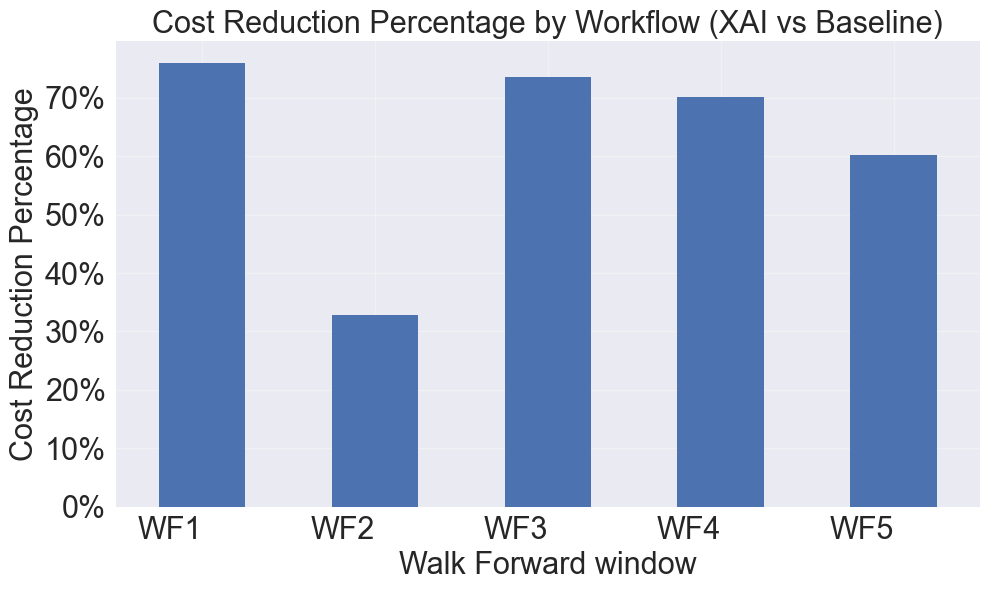

In [20]:
cost_pivot = summary_all.pivot(index='workflow', columns='variant', values='total_trade_cost_paid')
if 'xai_gated' in cost_pivot.columns and 'baseline' in cost_pivot.columns:
    cost_reduction_pct = 1 - cost_pivot['xai_gated'] / cost_pivot['baseline']
    ax = cost_reduction_pct.plot(kind='bar', figsize=(10, 6), fontsize=22)
    ax.set_title('Cost Reduction Percentage by Workflow (XAI vs Baseline)', fontsize=22)
    ax.set_xlabel('Walk Forward window', fontsize=22)
    ax.set_ylabel('Cost Reduction Percentage', fontsize=22)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right')
    plt.tight_layout()
else:
    print('total_trade_cost_paid not available in summary_all; skipping cost reduction plot')


## Minimal KPI Scorecard (WF1–WF5)

A smaller set of **high-signal** KPIs for each workflow:
- **XAI ending value (net)**
- **Δ ending value vs baseline (%)**
- **Orders reduction vs baseline (%)**
- **Cost reduction vs baseline (%)**
- **Avg cost per trade-event (XAI)**
- **Trade-event bars (XAI)**

In [ ]:
# Build a minimal, thesis-friendly scorecard
scorecard = pd.DataFrame(index=wide.index)

scorecard['EV (XAI)'] = wide['ending_value_net__xai_gated']
scorecard['EV Δ% (XAI vs Base)'] = wf_delta['ending_value_net_pct'] * 100.0
scorecard['Orders Red %'] = wf_delta['orders_reduction_pct'] * 100.0
scorecard['Cost Red %'] = wf_delta['cost_reduction_pct'] * 100.0

# Operational / frictions (still compact)
scorecard['Avg Cost / Trade-Event (XAI)'] = wide.get('avg_cost_per_trade_event__xai_gated')
scorecard['Trade-Event Bars (XAI)'] = wide.get('trade_event_bars__xai_gated')

# Simple ranking helpers (lower composite is better)
scorecard['Rank EV (XAI)'] = scorecard['EV (XAI)'].rank(ascending=False, method='min').astype(int)
scorecard['Rank Orders Red'] = scorecard['Orders Red %'].rank(ascending=False, method='min').astype(int)
scorecard['Rank Cost Red'] = scorecard['Cost Red %'].rank(ascending=False, method='min').astype(int)
scorecard['Composite Rank (sum)'] = (
    scorecard['Rank EV (XAI)'] + scorecard['Rank Orders Red'] + scorecard['Rank Cost Red']
)

scorecard = scorecard.sort_values(['Composite Rank (sum)', 'EV (XAI)'], ascending=[True, False])
scorecard

# Interactive table (Plotly) + fallback
if PLOTLY_AVAILABLE:
    header = dict(
        values=[f"<b>{c}</b>" for c in ['Workflow'] + list(scorecard.columns)],
        fill_color='#111827',
        font=dict(color='white', size=12),
        align='left'
    )

    # Color EV Δ%: green if positive, red if negative
    ev_delta = scorecard['EV Δ% (XAI vs Base)'].values
    ev_delta_colors = ['#dcfce7' if v >= 0 else '#fee2e2' for v in ev_delta]

    cols = [scorecard.index.tolist()] + [scorecard[c].tolist() for c in scorecard.columns]
    fill = ['#f9fafb'] + ['#ffffff'] * (len(scorecard.columns) - 1)

    # Apply column-level coloring to EV Δ%
    fill_colors = [
        ['#f9fafb'] * len(scorecard),
    ]
    for c in scorecard.columns:
        if c == 'EV Δ% (XAI vs Base)':
            fill_colors.append(ev_delta_colors)
        else:
            fill_colors.append(['#ffffff'] * len(scorecard))

    fig_tbl = go.Figure(data=[go.Table(
        header=header,
        cells=dict(
            values=cols,
            fill_color=fill_colors,
            align='left',
            format=[None] + [
                ".3f" if 'EV' in c and '%' not in c else (".2f" if '%' in c else None)
                for c in scorecard.columns
            ]
        )
    )])
    fig_tbl.update_layout(title='Minimal KPI Scorecard (interactive)')
    fig_tbl.show()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
if PLOTLY_AVAILABLE:
    fig1 = px.scatter(
        plot_df,
        x='orders_reduction_pct_100',
        y='ending_value_net_delta',
        color='ending_value_net_pct_100',
        size='trade_event_bars__xai_gated',   # FIXED
        hover_name='workflow',
        hover_data={
            'EV (XAI)': plot_df['ending_value_net__xai_gated'],
            'EV (Base)': plot_df['ending_value_net__baseline'],
            'Orders Red %': plot_df['orders_reduction_pct_100'],
            'Cost Red %': plot_df['cost_reduction_pct_100'],
        },
        title='Trade-off: Δ Ending Value vs Orders Reduction (WF1–WF5)'
    )

    fig1.update_layout(
        xaxis_title='Orders reduction vs baseline (%)',
        yaxis_title='Δ Ending value (XAI − baseline)'
    )

    fig1.show()

    fig2 = px.scatter(
        plot_df,
        x='cost_reduction_pct_100',
        y='ending_value_net_delta',
        color='ending_value_net_pct_100',
        size='trade_event_bars__xai_gated',   # FIXED
        hover_name='workflow',
        hover_data={
            'EV (XAI)': plot_df['ending_value_net__xai_gated'],
            'EV (Base)': plot_df['ending_value_net__baseline'],
            'Orders Red %': plot_df['orders_reduction_pct_100'],
            'Cost Red %': plot_df['cost_reduction_pct_100'],
        },
        title='Trade-off: Δ Ending Value vs Cost Reduction (WF1–WF5)'
    )

    fig2.update_layout(
        xaxis_title='Cost reduction vs baseline (%)',
        yaxis_title='Δ Ending value (XAI − baseline)'
    )

    fig2.show()

ValueError: Value of 'size' is not the name of a column in 'data_frame'. Expected one of ['workflow', 'ending_value_net_delta', 'ending_value_net_pct', 'orders_delta', 'orders_reduction_pct', 'cost_reduction_pct', 'ending_value_net__baseline', 'ending_value_net__xai_gated', 'orders_sum_abs_pos_change__baseline', 'orders_sum_abs_pos_change__xai_gated', 'trade_event_bars__baseline', 'trade_event_bars__xai_gated', 'orders_reduction_pct_100', 'cost_reduction_pct_100', 'ending_value_net_pct_100'] but received: total_trade_cost_paid__xai_gated

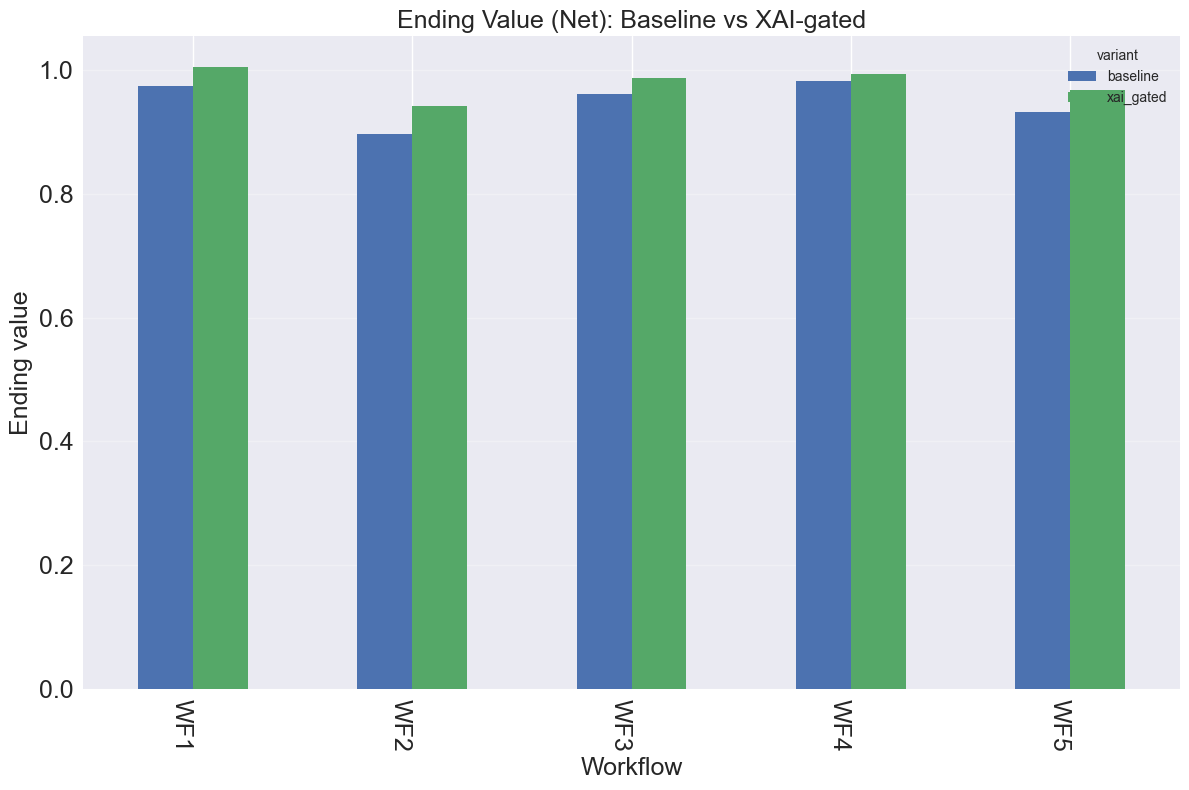

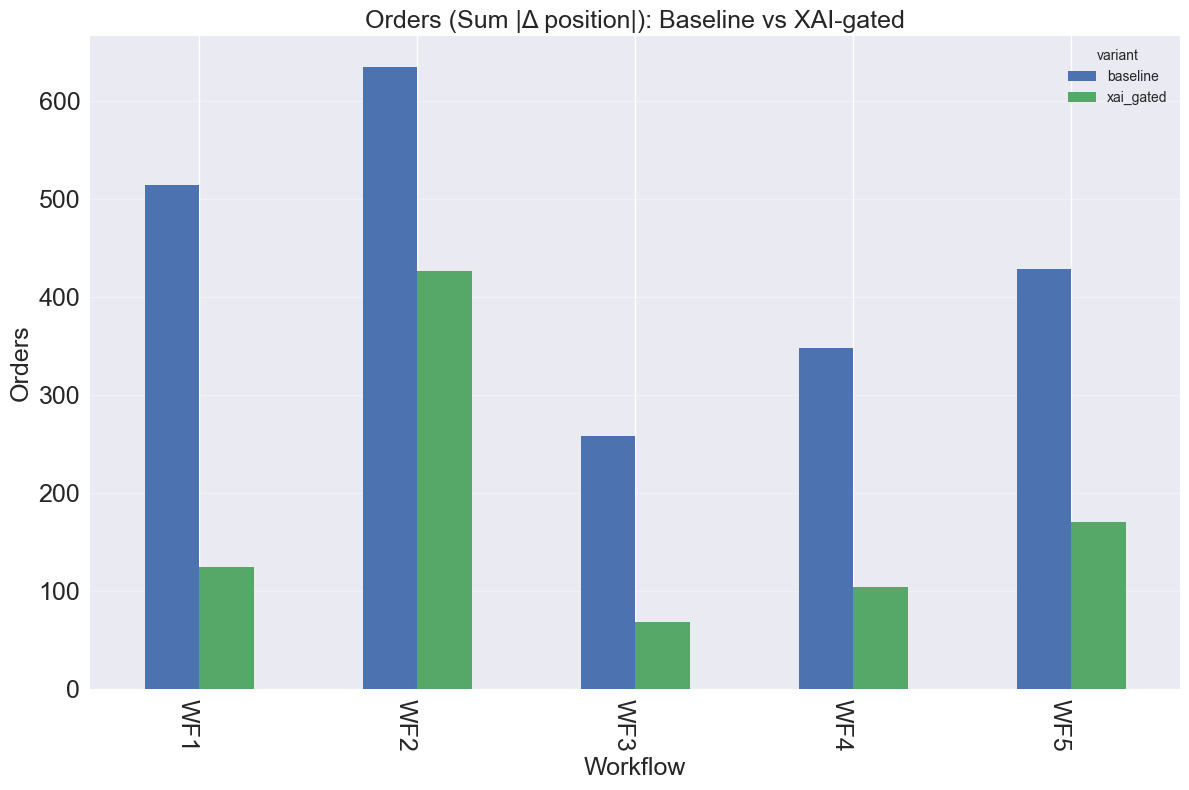

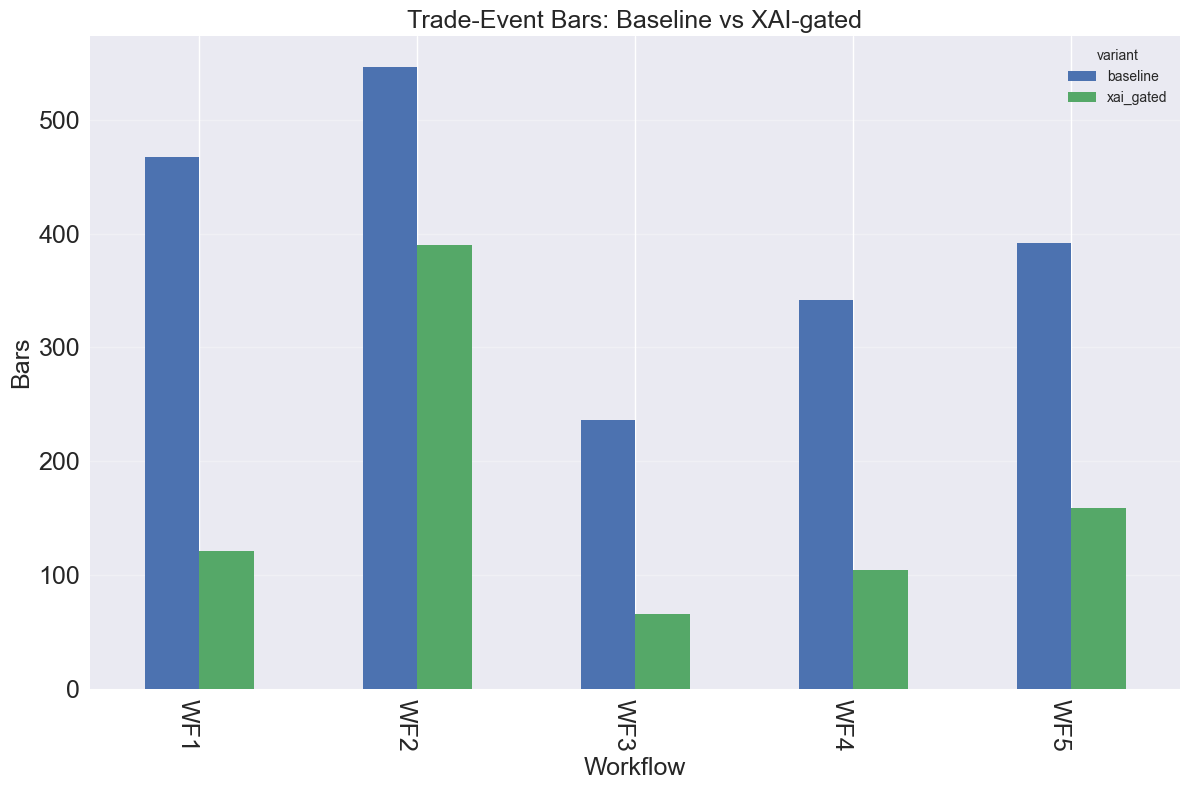

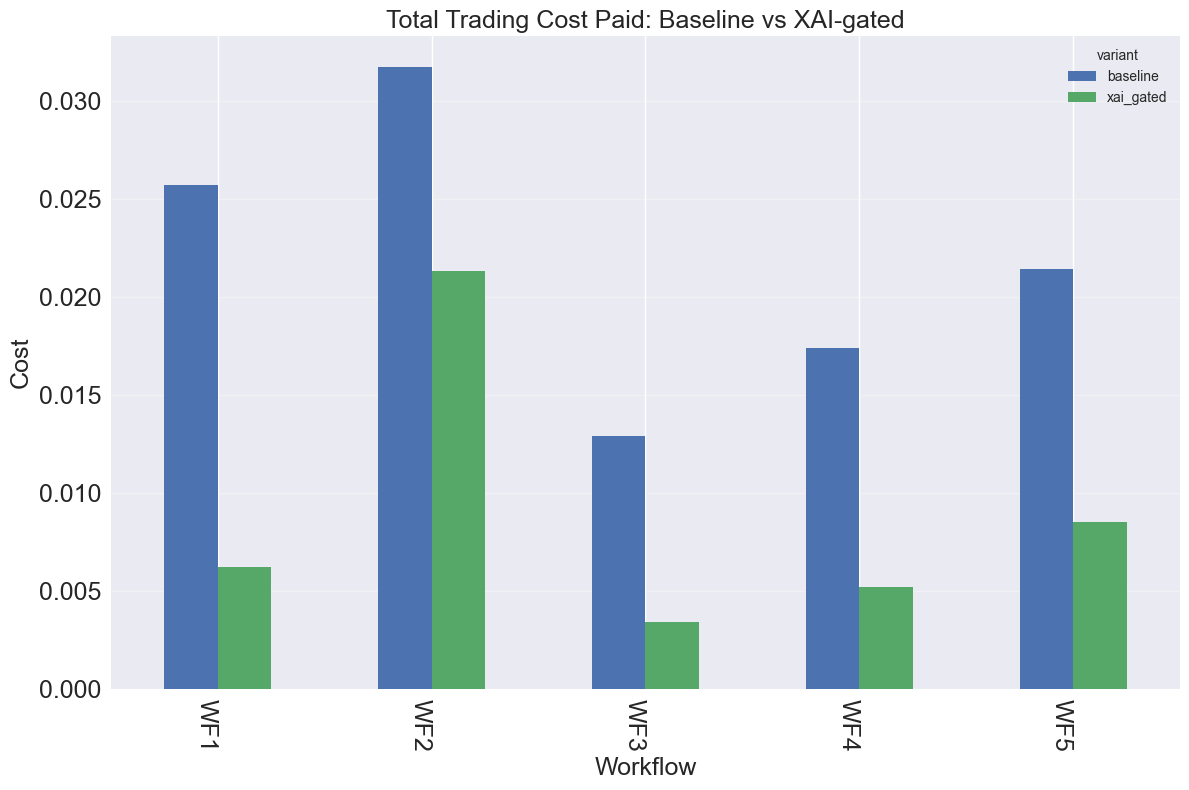

C:\Users\RAJ MANE\AppData\Local\Temp\ipykernel_3284\3767264696.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=-90, ha='right')


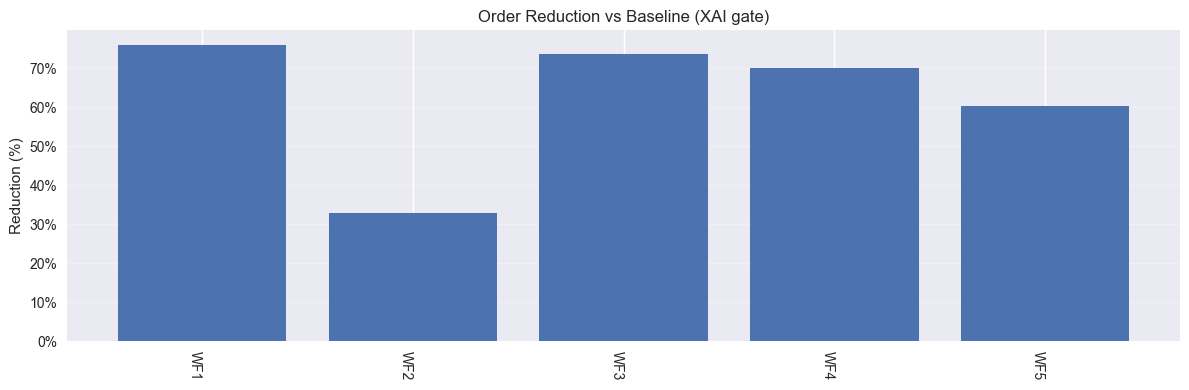

In [ ]:
# --- Figures ---

def grouped_bar(df, metric, title, ylabel=None):
    d = df.pivot(index='workflow', columns='variant', values=metric)
    d = d.reindex([f'WF{i}' for i in range(1, 6)])

    ax = d.plot(kind='bar', figsize=(12, 8), fontsize=18)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel('Workflow', fontsize=18)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=-90, ha='right')
    plt.tight_layout()
    plt.show()

grouped_bar(summary_all, 'ending_value_net', 'Ending Value (Net): Baseline vs XAI-gated', ylabel='Ending value')
grouped_bar(summary_all, 'orders_sum_abs_pos_change', 'Orders (Sum |Δ position|): Baseline vs XAI-gated', ylabel='Orders')
grouped_bar(summary_all, 'trade_event_bars', 'Trade-Event Bars: Baseline vs XAI-gated', ylabel='Bars')
grouped_bar(summary_all, 'total_trade_cost_paid', 'Total Trading Cost Paid: Baseline vs XAI-gated', ylabel='Cost')

# Order reduction as reported by the WF notebooks (xai_gated row only)
red = summary_all[summary_all['variant'] == 'xai_gated'][['workflow', 'order_reduction_vs_baseline']].copy()
red = red.set_index('workflow').reindex([f'WF{i}' for i in range(1, 6)])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(red.index, red['order_reduction_vs_baseline'] * 100.0)
ax.set_title('Order Reduction vs Baseline (XAI gate)')
ax.set_ylabel('Reduction (%)')
ax.grid(True, axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-90, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{x:.0f}%"))
plt.tight_layout()
plt.show()



In [ ]:
# Compact heatmap (direction-aware): green = better, red = worse
# Keep the metric set small and meaningful.
metrics = [
    'ending_value_net',            # higher is better
    'orders_sum_abs_pos_change',   # lower is better
    'total_trade_cost_paid',       # lower is better
    'avg_cost_per_trade_event',    # lower is better
]

M = summary_all.set_index(['workflow', 'variant'])[metrics].copy()
M = M.loc[[(f'WF{i}', v) for i in range(1, 6) for v in ['baseline', 'xai_gated']]]

# Normalize per metric (0..1). Then flip the 'lower is better' metrics so that higher always means better.
Mn = (M - M.min()) / (M.max() - M.min())

lower_is_better = {'orders_sum_abs_pos_change', 'total_trade_cost_paid', 'avg_cost_per_trade_event'}
Mn_better = Mn.copy()
for m in lower_is_better:
    if m in Mn_better.columns:
        Mn_better[m] = 1.0 - Mn_better[m]

if PLOTLY_AVAILABLE:
    fig_hm = px.imshow(
        Mn_better.values,
        x=metrics,
        y=[f'{wf} | {var}' for wf, var in Mn_better.index],
        color_continuous_scale='RdYlGn',
        aspect='auto',
        title='Compact “Higher is Better” Heatmap (WF × Variant)'
    )
    fig_hm.update_layout(coloraxis_colorbar=dict(title='Normalized'))
    fig_hm.show()
else:
    plt.figure(figsize=(12, 5))
    plt.imshow(Mn_better.values, aspect='auto')
    plt.colorbar(label='Normalized (higher=better)')
    plt.title('Compact “Higher is Better” Heatmap (WF × Variant)')
    plt.yticks(range(len(Mn_better.index)), [f'{wf} | {var}' for wf, var in Mn_better.index])
    plt.xticks(range(len(metrics)), metrics, rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

Mn_better

ending_value_net  orders_sum_abs_pos_change  \
workflow variant                                                  
WF1      baseline            0.72582                    0.21201   
         xai_gated           1.00000                    0.90106   
WF2      baseline            0.00000                    0.00000   
         xai_gated           0.41484                    0.36749   
WF3      baseline            0.60554                    0.66431   
         xai_gated           0.83414                    1.00000   
WF4      baseline            0.80254                    0.50530   
         xai_gated           0.90150                    0.93640   
WF5      baseline            0.33905                    0.36396   
         xai_gated           0.66531                    0.81979   

                    total_trade_cost_paid  avg_cost_per_trade_event  
workflow variant                                                     
WF1      baseline                 0.21201                   0.00000  
         xai_gated                0.90106                   1.00000  
WF2      baseline                 0.00000                   0.00000  
         xai_gated                0.36749                   1.00000  
WF3      baseline                 0.66431                   1.00000  
         xai_gated                1.00000                   1.00000  
WF4      baseline                 0.50530                   1.00000  
         xai_gated                0.93640                   1.00000  
WF5      baseline                 0.36396                   1.00000  
         xai_gated                0.81979                   1.00000

## Notes / Troubleshooting

- If you see **“No summary table found”**, open the corresponding WF notebook, run the final cell that creates `summary`, save, then re-run this notebook.
- This comparison notebook uses only metrics that were stored in the WF notebooks’ `summary` output table. If you want more metrics (Sharpe, max drawdown, CAGR, etc.), add them to the `summary` table inside each WF notebook and they’ll appear here automatically.

## Final Takeaway Figure

Rank the five workflows by **XAI-gated ending value (net)** and overlay how much trading was reduced (orders reduction %).

C:\Users\RAJ MANE\AppData\Local\Temp\ipykernel_3284\1417829965.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=-90, ha='right')


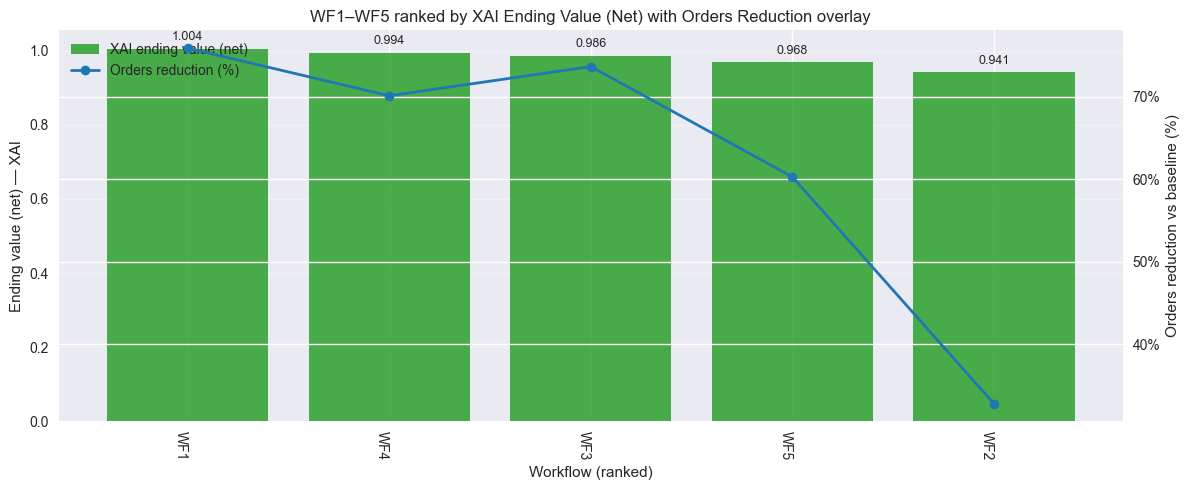

In [21]:
# Ensure the WF-level delta table exists (for robustness if running out-of-order)
if 'wf_delta' not in globals():
    wide_tmp = wide if 'wide' in globals() else None
    if wide_tmp is None:
        metrics_wide = [
            'ending_value_net',
            'orders_sum_abs_pos_change',
            'trade_event_bars',
            'total_trade_cost_paid',
            'avg_cost_per_trade_event',
            'avg_cost_per_order_unit',
        ]
        wide_tmp = (
            summary_all
            .set_index(['workflow', 'variant'])[metrics_wide]
            .unstack('variant')
            .reindex([f'WF{i}' for i in range(1, 6)])
            .sort_index()
        )
        wide_tmp.columns = [f"{m}__{v}" for m, v in wide_tmp.columns]
    wf_delta = pd.DataFrame(index=wide_tmp.index)
    wf_delta['ending_value_net_delta'] = wide_tmp['ending_value_net__xai_gated'] - wide_tmp['ending_value_net__baseline']
    wf_delta['orders_reduction_pct'] = 1 - (wide_tmp['orders_sum_abs_pos_change__xai_gated'] / wide_tmp['orders_sum_abs_pos_change__baseline'])

    # Compute cost_reduction_pct only if cost columns exist; otherwise set NaN
    if 'total_trade_cost_paid__xai_gated' in wide_tmp.columns and 'total_trade_cost_paid__baseline' in wide_tmp.columns:
        wf_delta['cost_reduction_pct'] = 1 - (wide_tmp['total_trade_cost_paid__xai_gated'] / wide_tmp['total_trade_cost_paid__baseline'])
    else:
        wf_delta['cost_reduction_pct'] = np.nan

# Rank by XAI-gated ending value
xai_ev = wide['ending_value_net__xai_gated'].copy()
order_red = (wf_delta['orders_reduction_pct'] * 100.0).copy()

order = xai_ev.sort_values(ascending=False).index
xai_ev = xai_ev.loc[order]
order_red = order_red.loc[order]

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(xai_ev.index, xai_ev.values, color='#2ca02c', alpha=0.85, label='XAI ending value (net)')
ax1.set_title('WF1–WF5 ranked by XAI Ending Value (Net) with Orders Reduction overlay')
ax1.set_xlabel('Workflow (ranked)')
ax1.set_ylabel('Ending value (net) — XAI')
ax1.grid(True, axis='y', alpha=0.3)

# Annotate bar values
for b in bars:
    ax1.annotate(f"{b.get_height():.3f}",
                 (b.get_x() + b.get_width() / 2, b.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 4), textcoords='offset points')

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=-90, ha='right')
ax2 = ax1.twinx()
ax2.plot(order_red.index, order_red.values, color='#1f77b4', marker='o', linewidth=2, label='Orders reduction (%)')
ax2.set_ylabel('Orders reduction vs baseline (%)')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{x:.0f}%"))

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()